importing libraries, check tensorflow version and CPU

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("All imports successful")

All imports successful


In [3]:
print("TensorFlow version:", tf.__version__)

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

print("Num CPUs Available:", len(tf.config.list_physical_devices('CPU')))

TensorFlow version: 2.16.2
Num GPUs Available: 1
Num CPUs Available: 1


In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [5]:
a = tf.constant([1, 2, 3])
b = tf.constant([4, 5, 6])

print("TensorFlow test:", tf.add(a, b))

TensorFlow test: tf.Tensor([5 7 9], shape=(3,), dtype=int32)


2026-03-30 17:42:18.936469: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-30 17:42:18.936670: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-30 17:42:18.936685: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-30 17:42:18.937133: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-30 17:42:18.937520: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
# test model
model = keras.Sequential([
    layers.Dense(10, activation='relu', input_shape=(5,)),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Dummy data
X = np.random.rand(100, 5)
y = np.random.rand(100)

# Train briefly
model.fit(X, y, epochs=2, verbose=1)

print("Keras model ran successfully")

/opt/anaconda3/envs/pysparkenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2


2026-03-30 17:42:20.847505: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-03-30 17:42:20.852615: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - loss: 1.0672
Epoch 2/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9895
Keras model ran successfully ✅


load metadata and images

In [12]:
df = pd.read_csv("data/metadata")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [13]:
image_dir = "data/images"

df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(image_dir, x + ".jpg")
)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,data/images/ISIC_0031633.jpg


In [14]:
print("Missing images:", df["image_path"].apply(lambda x: not os.path.exists(x)).sum())

Missing images: 0


In [15]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'dataset', 'image_path'],
      dtype='object')

In [16]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [17]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dataset          0
image_path       0
dtype: int64

In [19]:
df["age"] = df["age"].fillna(df["age"].median())

df["sex"] = df["sex"].fillna("unknown")

df["localization"] = df["localization"].fillna("unknown")

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

df[["dx", "label"]].head()

,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [21]:
df = pd.get_dummies(df, columns=["sex", "localization"])

In [23]:
y = df["label"]

X_meta = df.drop(columns=[
    "lesion_id",
    "image_id",
    "dx",
    "dx_type",
    "dataset",
    "image_path",
    "label"
])

In [26]:
df.head()

,lesion_id,image_id,dx,dx_type,age,dataset,image_path,label,sex_female,sex_male,...,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,vidir_modern,data/images/ISIC_0027419.jpg,2,False,True,...,False,False,False,False,False,False,True,False,False,False
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,vidir_modern,data/images/ISIC_0025030.jpg,2,False,True,...,False,False,False,False,False,False,True,False,False,False
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,vidir_modern,data/images/ISIC_0026769.jpg,2,False,True,...,False,False,False,False,False,False,True,False,False,False
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,vidir_modern,data/images/ISIC_0025661.jpg,2,False,True,...,False,False,False,False,False,False,True,False,False,False
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,vidir_modern,data/images/ISIC_0031633.jpg,2,False,True,...,False,False,False,False,False,False,False,False,False,False


In [29]:
for i, class_name in enumerate(le.classes_):
    print(i, ":", class_name)

0 : akiec
1 : bcc
2 : bkl
3 : df
4 : mel
5 : nv
6 : vasc


stratifiedfold

In [30]:
# Labels
y = df["label"]

# Image paths
X_images = df["image_path"]

# Metadata features only
X_meta = df.drop(columns=[
    "lesion_id",
    "image_id",
    "dx",
    "dx_type",
    "dataset",
    "image_path",
    "label"
])

print("Metadata shape:", X_meta.shape)
print("Images:", X_images.shape)
print("Labels:", y.shape)

Metadata shape: (10015, 19)
Images: (10015,)
Labels: (10015,)


In [31]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [32]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta, y), start=1):
    X_meta_train = X_meta.iloc[train_idx]
    X_meta_val = X_meta.iloc[val_idx]

    X_img_train = X_images.iloc[train_idx]
    X_img_val = X_images.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    print(f"Fold {fold}")
    print("Train size:", len(train_idx))
    print("Val size:", len(val_idx))
    print("Train label counts:")
    print(y_train.value_counts().sort_index())
    print("Val label counts:")
    print(y_val.value_counts().sort_index())
    print("-" * 40)

    break

Fold 1
Train size: 8012
Val size: 2003
Train label counts:
label
0     262
1     411
2     879
3      92
4     890
5    5364
6     114
Name: count, dtype: int64
Val label counts:
label
0      65
1     103
2     220
3      23
4     223
5    1341
6      28
Name: count, dtype: int64
----------------------------------------


In [33]:
print("Image path:", X_img_train.iloc[0])
print("\nMetadata row:")
print(X_meta_train.iloc[0])
print("\nLabel:", y_train.iloc[0])

Image path: data/images/ISIC_0027419.jpg

Metadata row:
age                              80.0
sex_female                      False
sex_male                         True
sex_unknown                     False
localization_abdomen            False
localization_acral              False
localization_back               False
localization_chest              False
localization_ear                False
localization_face               False
localization_foot               False
localization_genital            False
localization_hand               False
localization_lower extremity    False
localization_neck               False
localization_scalp               True
localization_trunk              False
localization_unknown            False
localization_upper extremity    False
Name: 0, dtype: object

Label: 2


In [34]:
folds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta, y), start=1):
    fold_data = {
        "fold": fold,
        "X_meta_train": X_meta.iloc[train_idx],
        "X_meta_val": X_meta.iloc[val_idx],
        "X_img_train": X_images.iloc[train_idx],
        "X_img_val": X_images.iloc[val_idx],
        "y_train": y.iloc[train_idx],
        "y_val": y.iloc[val_idx]
    }
    folds.append(fold_data)

print("Number of folds saved:", len(folds))

Number of folds saved: 5


In [35]:
bool_cols = X_meta.select_dtypes(include=["bool"]).columns
X_meta[bool_cols] = X_meta[bool_cols].astype(int)

In [36]:
folds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta, y), start=1):
    fold_data = {
        "fold": fold,
        "X_meta_train": X_meta.iloc[train_idx].reset_index(drop=True),
        "X_meta_val": X_meta.iloc[val_idx].reset_index(drop=True),
        "X_img_train": X_images.iloc[train_idx].reset_index(drop=True),
        "X_img_val": X_images.iloc[val_idx].reset_index(drop=True),
        "y_train": y.iloc[train_idx].reset_index(drop=True),
        "y_val": y.iloc[val_idx].reset_index(drop=True)
    }
    folds.append(fold_data)

image preprocessing and feature extraction

In [38]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np

# Load model WITHOUT top layer
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"   # gives feature vector directly
)

print("Model loaded")

/var/folders/fj/jj9hkmp960q3_hshpdf9t6jc0000gn/T/ipykernel_53467/2040902263.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step 
Model loaded


In [39]:
from PIL import Image

def extract_features(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))

    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    features = base_model.predict(img_array, verbose=0)
    return features[0]

In [40]:
test_img = folds[0]["X_img_train"].iloc[0]

features = extract_features(test_img)

print("Feature shape:", features.shape)

2026-03-30 18:12:50.125007: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Feature shape: (1280,)


In [41]:
from PIL import Image
import numpy as np

def load_and_preprocess_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    return preprocess_input(img_array)

def extract_features_batch(image_paths, batch_size=32):
    all_features = []
    
    for start in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[start:start + batch_size]
        batch_images = np.array([load_and_preprocess_image(p) for p in batch_paths])
        
        batch_features = base_model.predict(batch_images, verbose=0)
        all_features.append(batch_features)
        
        print(f"Processed {min(start + batch_size, len(image_paths))} / {len(image_paths)}")
    
    return np.vstack(all_features)

In [42]:
sample_paths = folds[0]["X_img_train"].iloc[:64].tolist()
sample_features = extract_features_batch(sample_paths, batch_size=16)

print("Sample feature matrix shape:", sample_features.shape)

2026-03-30 18:14:12.853264: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Processed 16 / 64
Processed 32 / 64
Processed 48 / 64
Processed 64 / 64
Sample feature matrix shape: (64, 1280)


In [43]:
X_img_train_fold1 = folds[0]["X_img_train"].tolist()
X_img_val_fold1 = folds[0]["X_img_val"].tolist()

X_train_img_features = extract_features_batch(X_img_train_fold1, batch_size=16)
X_val_img_features = extract_features_batch(X_img_val_fold1, batch_size=16)

print("Train image features shape:", X_train_img_features.shape)
print("Val image features shape:", X_val_img_features.shape)

Processed 16 / 8012
Processed 32 / 8012
Processed 48 / 8012
Processed 64 / 8012
Processed 80 / 8012
Processed 96 / 8012
Processed 112 / 8012
Processed 128 / 8012
Processed 144 / 8012
Processed 160 / 8012
Processed 176 / 8012
Processed 192 / 8012
Processed 208 / 8012
Processed 224 / 8012
Processed 240 / 8012
Processed 256 / 8012
Processed 272 / 8012
Processed 288 / 8012
Processed 304 / 8012
Processed 320 / 8012
Processed 336 / 8012
Processed 352 / 8012
Processed 368 / 8012
Processed 384 / 8012
Processed 400 / 8012
Processed 416 / 8012
Processed 432 / 8012
Processed 448 / 8012
Processed 464 / 8012
Processed 480 / 8012
Processed 496 / 8012
Processed 512 / 8012
Processed 528 / 8012
Processed 544 / 8012
Processed 560 / 8012
Processed 576 / 8012
Processed 592 / 8012
Processed 608 / 8012
Processed 624 / 8012
Processed 640 / 8012
Processed 656 / 8012
Processed 672 / 8012
Processed 688 / 8012
Processed 704 / 8012
Processed 720 / 8012
Processed 736 / 8012
Processed 752 / 8012
Processed 768 / 801

In [44]:
X_train_meta = folds[0]["X_meta_train"].to_numpy(dtype=np.float32)
X_val_meta = folds[0]["X_meta_val"].to_numpy(dtype=np.float32)

print("Train metadata shape:", X_train_meta.shape)
print("Val metadata shape:", X_val_meta.shape)

Train metadata shape: (8012, 19)
Val metadata shape: (2003, 19)


In [45]:
X_train_combined = np.concatenate([X_train_img_features, X_train_meta], axis=1)
X_val_combined = np.concatenate([X_val_img_features, X_val_meta], axis=1)

print("Combined train shape:", X_train_combined.shape)
print("Combined val shape:", X_val_combined.shape)

Combined train shape: (8012, 1299)
Combined val shape: (2003, 1299)


In [47]:
class_names = le.classes_
num_classes = len(class_names)

classifier = keras.Sequential([
    keras.Input(shape=(X_train_combined.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = classifier.fit(
    X_train_combined,
    folds[0]["y_train"].to_numpy(),
    validation_data=(X_val_combined, folds[0]["y_val"].to_numpy()),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10


2026-03-30 18:20:07.755489: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7031 - loss: 0.9344 - val_accuracy: 0.7404 - val_loss: 0.7616
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7493 - loss: 0.7087 - val_accuracy: 0.7718 - val_loss: 0.6862
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7695 - loss: 0.6440 - val_accuracy: 0.7783 - val_loss: 0.6276
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7796 - loss: 0.6104 - val_accuracy: 0.7878 - val_loss: 0.5909
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7897 - loss: 0.5668 - val_accuracy: 0.7853 - val_loss: 0.5796
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8038 - loss: 0.5371 - val_accuracy: 0.7888 - val_loss: 0.5940
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8097 - loss: 0.5073 - val_accuracy: 0.7903 - val_loss: 0.5724
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8145 - loss: 0.4955 - val_accuracy: 0.7983 - val

In [48]:
from sklearn.metrics import classification_report

y_pred = classifier.predict(X_val_combined)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(
    folds[0]["y_val"],
    y_pred_classes,
    target_names=class_names
))

26/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   

2026-03-30 18:22:56.916866: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

       akiec       0.59      0.25      0.35        65
         bcc       0.58      0.61      0.59       103
         bkl       0.63      0.56      0.59       220
          df       0.33      0.04      0.08        23
         mel       0.61      0.42      0.50       223
          nv       0.86      0.96      0.90      1341
        vasc       0.94      0.57      0.71        28

    accuracy                           0.80      2003
   macro avg       0.65      0.49      0.53      2003
weighted avg       0.78      0.80      0.78      2003



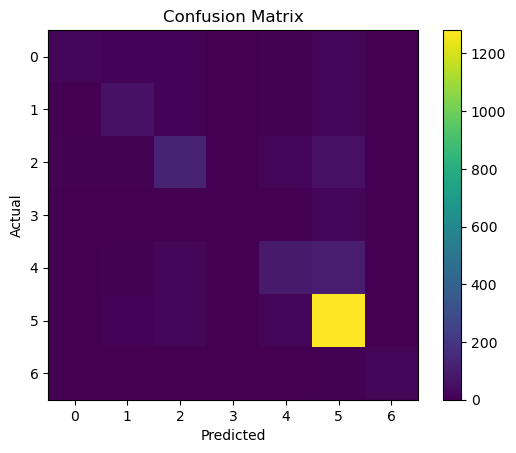

In [49]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(folds[0]["y_val"], y_pred_classes)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(
    folds[0]["X_meta_train"],
    folds[0]["y_train"]
)

importances = rf.feature_importances_
feature_names = folds[0]["X_meta_train"].columns

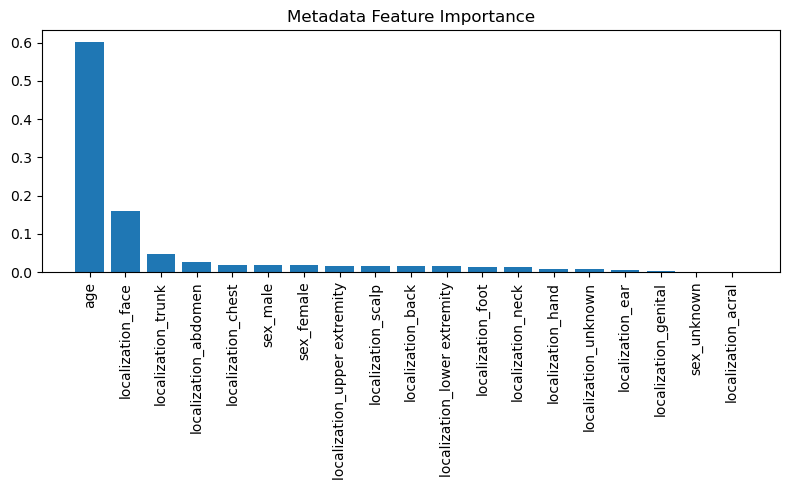

In [51]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.title("Metadata Feature Importance")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(folds[0]["y_train"]),
    y=folds[0]["y_train"]
)

class_weights = dict(enumerate(class_weights))

In [ ]:
classifier.fit(..., class_weight=class_weights)